### Lab: Generative AI for Models Development
### Estimated time: 30 minutes
In this lab, we will use generative AI to create Python scripts to develop and evaluate different predictive models for a given data set.

Learning objectives
In this lab, you will learn how to use generative AI to create Python codes that can:

Use linear regression in one variable to fit the parameters to a model
Use linear regression in multiple variables to fit the parameters to a model
Use polynomial regression in a single variable to fit the parameters to a model
Create a pipeline for performing linear regression using multiple features in polynomial scaling
Use the grid search with cross-validation and ridge regression to create a model with optimum hyperparameters
About generative AI classroom lab
Click here
Notes:

The prompts used in this lab are for your reference only. You can create your own prompts and generate responses using generative AI.
Since AI-generated outputs are dynamic, you may receive different responses even though you've used the same prompt from this lab.
Code execution environment
To test the prompt-generated code, keep the Jupyter Notebook (in the link below) open in a separate tab in your web browser. The notebook has some setup instructions that you should complete now.

Jupyter-Lite Test Environment

The data set for this lab is available in the following URL.





In [3]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

The dataset is a filtered and modified version of the Laptop Price Prediction using specifications dataset, available under the Database Contents License (DbCL) v1.0 on the Kaggle website.

Complete the setup in the Jupyter Notebook and then proceed further.

### Building the prompt: Importing data set
Now you will start building your prompt. You can set the prompt like below to get a defined output:


The first step is to ask the Gen AI model to generate a code to import the provided dataset to a Pandas' data frame. You must specify if you imported the data. Then, you should see the dataset headers in the first row of the CSV file.

You can structure the prompt to create the code as follows:


Write a Python code that can perform the following tasks.
Read the CSV file, located on a given file path, into a pandas data frame, assuming that the first row of the file can be used as the headers for the data.


Running this prompt using the GPT-5 Nano engine in the GenAI classroom should result in a response that contains the code, as shown below.


In [51]:
# Reads a CSV from the provided file path into a pandas DataFrame, using the first row as column headers.
import pandas as pd
file_path = URL
df = pd.read_csv(file_path, header=0)
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


### Linear regression in one variable
You can now ask the generative AI model to generate a script to create a linear regression model using a single attribute as the training feature to predict a target attribute.

You can write the prompt as follows:


Write a Python code that performs the following tasks.
1. Develops and trains a linear regression model that uses one attribute of a data frame as the source variable and another as a target variable.
2. Calculate and display the MSE and R^2 values for the trained model.


It will generate a response as shown below:



In [18]:
# Reads a CSV into a DataFrame, selects one feature as X and one as y, trains a simple linear regression, and computes MSE and R^2 on the training data.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select source and target columns
source_column = 'CPU_frequency'  # Replace with your source variable column name
target_column = 'Price'          # Replace with your target variable column name

# Drop rows with missing values in the selected columns
df = df[[source_column, target_column]].dropna()

# Features (X) and target (y)
X = df[[source_column]]  # Use source_column as the feature
y = df[target_column]    # Use target_column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")


Mean Squared Error (MSE): 239035.9942943604
R-squared (R²): -0.037194178334964745


You can use this code to develop a linear regression model with the target variable as Price and the source variable as CPU_frequency. Try this out in the Test environment.

### Linear regression in multiple variables
You can modify the prompt to ask for a code that uses multiple attributes as input for training a model to predict the value of a target variable.

For that, you can use the prompt as shown below:

Write a Python code that performs the following tasks.
1. Develops and trains a linear regression model that uses some attributes of a data frame as the source variables and one of the attributes as a target variable.
2. Calculate and display the MSE and R^2 values for the trained model.


You should see a similar response to the following:

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select the source variables (features) and the target variable
source_columns = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Screen_Size_inch']  # Replace with the actual source columns
target_column = 'Price'  # Replace with the target variable column name

# Drop rows with missing values in the selected columns
df = df[source_columns + [target_column]].dropna()

# Features (X) and target (y)
X = df[source_columns]  # Use selected source columns as features
y = df[target_column]    # Use the target column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")


Mean Squared Error (MSE): 199393.60745295463
R-squared (R²): 0.13481695734602983


You can use the generated code and build a linear regression model for the data set that uses CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category and source variables and Price as the target variable. You can check the code generated in the webpage browser.

You may compare the performance of the two models by comparing their MSE and R^2 values.

### Polynomial regression
You can explore creating a model that uses higher-order features from original attributes. Higher orders of the same feature allow better generalization on the target variable. It is called polynomial regression, and you can use Generative AI to create a code for this.

Assume you are given a single attribute as the source variable and one as a target variable. You must create a model using polynomial regression for a given order. You can also make the model for different order values and compare their performance based on MSE and R^2 scores.

You can write a similar prompt to the following code:

Write a Python code that performs the following tasks.
1. Develops and trains multiple polynomial regression models, with orders 2, 3, and 5, that use one attribute of a data frame as the source variable and another as a target variable.
2. Calculate and display the MSE and R^2 values for the trained models.
3. Compare the performance of the models.


The expected output should look as shown below:

C:\Users\mukes\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


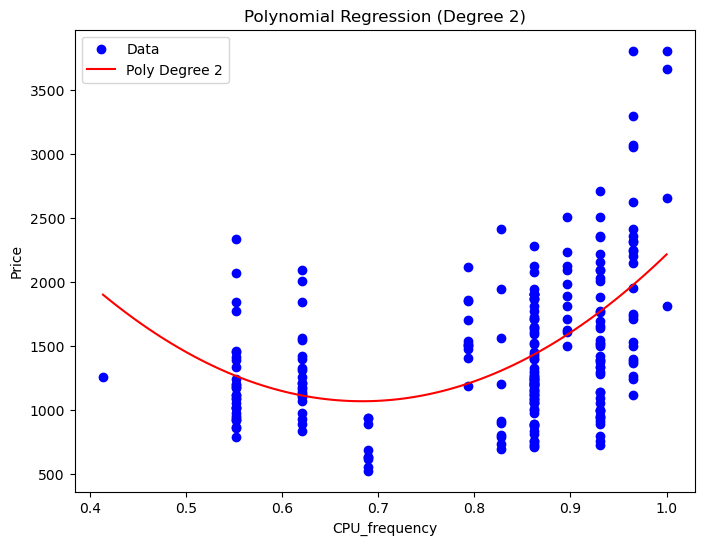

C:\Users\mukes\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


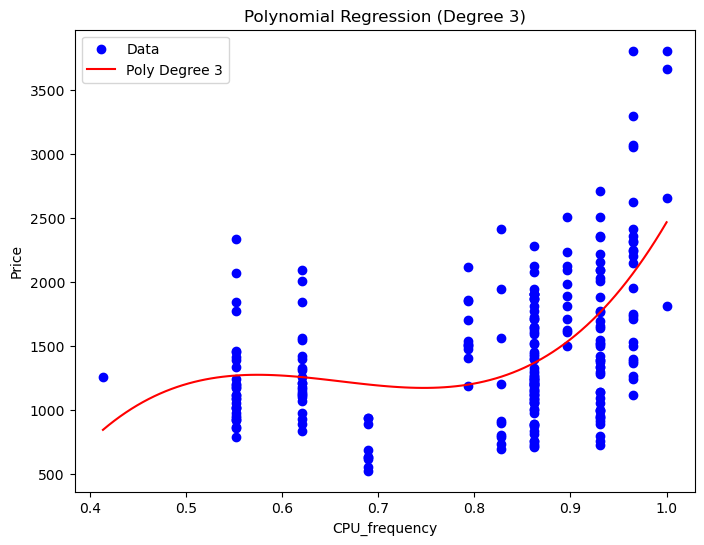

C:\Users\mukes\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


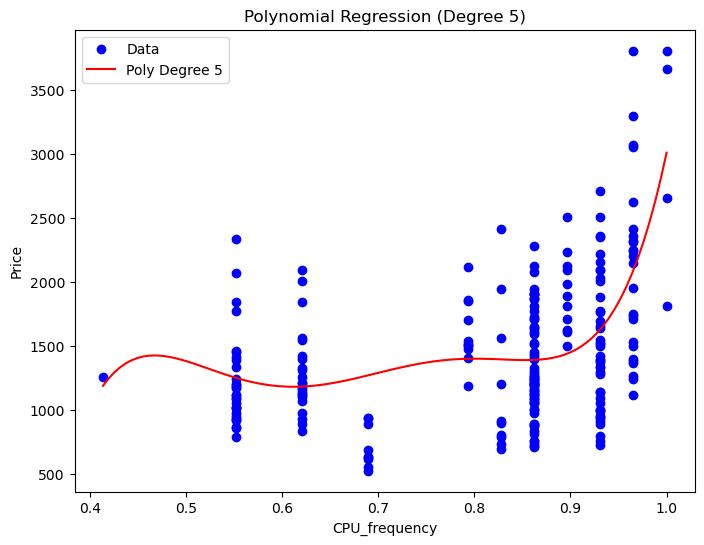

Model Performance Comparison (MSE & R^2):
Degree 2 -> MSE: 196263.5615, R²: 0.1484
Degree 3 -> MSE: 205918.0302, R²: 0.1065
Degree 5 -> MSE: 207335.7036, R²: 0.1004


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select source and target columns
source_column = 'CPU_frequency'  # Replace with your source variable column name
target_column = 'Price'          # Replace with your target variable column name

# Drop rows with missing values in the selected columns
df = df[[source_column, target_column]].dropna()

# Features (X) and target (y)
X = df[[source_column]]  # Use source_column as the feature
y = df[target_column]    # Use target_column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to perform Polynomial Regression with a given degree
def polynomial_regression(degree):
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    # Train the linear regression model on polynomial features
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_poly_test)
    
    # Calculate Mean Squared Error (MSE) and R-squared (R²)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return mse, r2, model, poly

# Create models for different polynomial degrees (2, 3, 5)
degrees = [2, 3, 5]
results = {}

for degree in degrees:
    mse, r2, model, poly = polynomial_regression(degree)
    results[degree] = {'MSE': mse, 'R2': r2, 'Model': model, 'Polynomial': poly}
    
    # Plotting the model's predictions
    plt.figure(figsize=(8, 6))
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_pred = model.predict(X_range_poly)
    
    plt.scatter(X, y, color='blue', label='Data')
    plt.plot(X_range, y_range_pred, color='red', label=f'Poly Degree {degree}')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.xlabel(source_column)
    plt.ylabel(target_column)
    plt.legend()
    plt.show()

# Display the performance comparison of the models
print("Model Performance Comparison (MSE & R^2):")
for degree in degrees:
    mse = results[degree]['MSE']
    r2 = results[degree]['R2']
    print(f"Degree {degree} -> MSE: {mse:.4f}, R²: {r2:.4f}")


You can use the relevant part of the code in your script.

You can see that the model can generate sophisticated code using functions to create and train models with different orders and evaluate their performance for each of them.

Try to run the generated code on the testing interface with the source variable as CPU frequency and the target variable as Price.

### Creating a Pipeline
Pipelines are processes containing a sequence of steps that lead to creating a trained model.

You will now use the Generative AI model to create a pipeline for performing feature scaling, creating polynomial features for multiple attributes, and performing linear regression using these variables.

You can build a similar prompt to the following code:

Write a Python code that performs the following tasks.
1. Create a pipeline that performs parameter scaling, Polynomial Feature generation, and Linear regression. Use the set of multiple features as before to create this pipeline.
2. Calculate and display the MSE and R^2 values for the trained model.

The expected response is as shown below:

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select the source variables (features) and the target variable
source_columns = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Screen_Size_inch']  # Replace with the actual source columns
target_column = 'Price'  # Replace with the target variable column name

# Drop rows with missing values in the selected columns
df = df[source_columns + [target_column]].dropna()

# Features (X) and target (y)
X = df[source_columns]  # Use selected source columns as features
y = df[target_column]    # Use the target column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling, polynomial feature generation, and linear regression
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),                    # Step 1: Standard Scaling
    ('polynomial', PolynomialFeatures(degree=2)),     # Step 2: Polynomial feature generation (degree=2)
    ('linear_regression', LinearRegression())         # Step 3: Linear regression model
])

# Train the model using the pipeline
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Squared Error (MSE): 166375.9987
R-squared (R²): 0.2781


You can use the relevant part in your code.

Make appropriate changes to the attributes you will use in the code. Consider the same set of attributes as used for multiple feature linear regression, which is CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category as source variables, and Price as the target variable.

### Grid search and Ridge regression
An improved way to train your model is to use ridge regression instead of linear regression. You can use the polynomial features of multiple attributes. One of the key factors of ridge regression is using the parameter alpha as a hyperparameter for training. Using grid search, one can determine the optimum value of the hyperparameter for the given set of features. Grid search also uses cross-validation training to train and prepare the optimum model.

You can use generative AI to create the Python code to perform a grid search for the optimum ridge regression model, which uses polynomial features generated from multiple parameters.

You may use the following prompt to create this:


Write a Python code that performs the following tasks.
1. Use polynomial features for some of the attributes of a data frame.
2. Perform Grid search on a ridge regression model for a set of values of hyperparameter alpha and polynomial features as input.
3. Use cross-validation in the Grid search.
4. Evaluate the resulting model's MSE and R^2 values.

The resulting code will look as shown below:

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select the source variables (features) and the target variable
source_columns = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Screen_Size_inch']  # Replace with your source columns
target_column = 'Price'  # Replace with your target column name

# Drop rows with missing values in the selected columns
df = df[source_columns + [target_column]].dropna()

# Features (X) and target (y)
X = df[source_columns]  # Use selected source columns as features
y = df[target_column]    # Use the target column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling, polynomial feature generation, and ridge regression
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),                    # Step 1: Standard Scaling
    ('polynomial', PolynomialFeatures()),             # Step 2: Polynomial feature generation (degree=2 by default)
    ('ridge_regression', Ridge())                    # Step 3: Ridge regression model
])

# Define the range of hyperparameters for the Grid Search
param_grid = {
    'polynomial__degree': [2, 3, 4],  # Polynomial degrees to try
    'ridge_regression__alpha': [0.1, 1, 10, 100]  # Ridge regularization parameters to try
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Train the model using GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the best parameters and the evaluation metrics
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Best Parameters: {'polynomial__degree': 2, 'ridge_regression__alpha': 10}
Mean Squared Error (MSE): 160943.1781
R-squared (R²): 0.3017


You can test this code for the data set on the testing environment.

You make use of the following parametric values for this purpose.

Source Variables: CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category
Target Variable: Price
Set of values for alpha: 0.0001,0.001,0.01, 0.1, 1, 10
Cross Validation: 4-fold
Polynomial Feature order: 2

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the data is in a DataFrame called df
# Example: loading data from a CSV
# df = pd.read_csv('your_data.csv')

# Select the source variables (features) and the target variable
source_columns = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']  # Adjusted based on your input
target_column = 'Price'  # The target variable

# Drop rows with missing values in the selected columns
df = df[source_columns + [target_column]].dropna()

# Features (X) and target (y)
X = df[source_columns]  # Use selected source columns as features
y = df[target_column]    # Use the target column as the target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling, polynomial feature generation, and ridge regression
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),                    # Step 1: Standard Scaling
    ('polynomial', PolynomialFeatures(degree=2)),     # Step 2: Polynomial feature generation (degree=2)
    ('ridge_regression', Ridge())                    # Step 3: Ridge regression model
])

# Define the range of hyperparameters for the Grid Search
param_grid = {
    'polynomial__degree': [2],  # Polynomial degree to try (fixed to 2 as per your requirement)
    'ridge_regression__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]  # Ridge regularization parameters to try
}

# Set up GridSearchCV with 4-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=4, scoring='neg_mean_squared_error', n_jobs=-1)

# Train the model using GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the best parameters and the evaluation metrics
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Best Parameters: {'polynomial__degree': 2, 'ridge_regression__alpha': 10}
Mean Squared Error (MSE): 233541.9930
R-squared (R²): -0.0134


### Conclusion
Congratulations! You have completed the lab on Data preparation.

With this, you have learned how to use generative AI to create Python codes that can:

Implement linear regression in single variable
Implement linear regression in multiple variables
Implement polynomial regression for different orders of a single variable
Create a pipeline that implements polynomial scaling for multiple variables and performs linear regression on them
Apply a grid search to create an optimum ridge regression model for multiple features